# Resample from WCRP/AR6-constrained posteriors to match MM-PPE for ECS
i.e., if we hold ECS "constant" by not changing the distribution, how much of an impact does that have on the future temperature?


In [1]:
import pickle

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

from scipy.stats import rankdata


In [2]:
fair_proj = "/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/_revisions2/fair_projections/"
fair_out = "/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/_revisions2/fair_Sherwood_ECS__SSP1-2.6/"

pickle_path = "/glade/u/home/jnug/work/multi_PPE_data/pickle_jar/"
file_path = "/glade/work/jnug/multi_PPE_data/annual_means/"

save_dir = "/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/_revisions2/figures/"


In [3]:
def get_matched_indices(source_arr, target_arr, n_target=1000):
    """
    Resample source array to match the shape of the distribution of
    a target array. Returns resampled indices of arr1.
    """
    rng = np.random.default_rng(seed=20260610)
    
    selected = []
    if n_target is None:
        n_target = len(target_arr)
        
    bins = np.linspace(min(source_arr.min(), target_arr.min()), max(source_arr.max(), target_arr.max()), 30)
    
    h1, _ = np.histogram(source_arr, bins)
    h2, _ = np.histogram(target_arr, bins)
    p2 = h2 / h2.sum()

    for i in range(len(bins)-1):
        idx = np.where((source_arr >= bins[i]) & (source_arr < bins[i+1]))[0]
        desired = int(round(p2[i]*n_target))
    
        if len(idx) > 0:
            replace = desired > len(idx)
            selected.extend(rng.choice(idx, size=desired, replace=replace))
    
    selected = np.array(selected)

    return selected


### Get the saved temperature projections
From the `FaIR_projections_SSP*` notebooks. These are constrained by ECS, TOA energy imbalance, historical temperature change, and limited to either ERFaci range.

In [4]:
# fully unconstrained
ds_uc = xr.open_dataset(fair_out + "CMIP6_aggregate_all__SSP126__Sherwood_ECS_WCRP_prior__temp_projections.nc")

# constrained
ds_wcrp = xr.open_dataset(fair_proj + "fair_output_WCRP_AR6_full_constraints__SSP1-2.6.nc")
ds_mmppe = xr.open_dataset(fair_proj + "fair_output_MM-PPE_AR6_full_constraints__SSP1-2.6.nc")


In [5]:
# # try SSP 2-4.5
# fair_out = "/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/_revisions2/fair_Sherwood_ECS__SSP2-4.5/"

# # fully unconstrained
# ds_uc = xr.open_dataset(fair_out + "CMIP6_aggregate_all__SSP245__Sherwood_ECS_WCRP_prior__temp_projections.nc")

# # constrained
# ds_wcrp = xr.open_dataset(fair_proj + "fair_output_WCRP_AR6_full_constraints__SSP2-4.6.nc")
# ds_mmppe = xr.open_dataset(fair_proj + "fair_output_MM-PPE_AR6_full_constraints__SSP2-4.6.nc")


### Match/resample

Resample so that WCRP/AR6 ECS posterior distribution matches the MM-PPE/AR6 ECS posterior [**allow only ERFaci to change**] 


In [6]:
# 1. match ECS
matched_ecs = get_matched_indices(ds_wcrp["ECS"], ds_mmppe["ECS"])
wcrp_ecs_resampled = ds_wcrp.isel(ensemble=matched_ecs)

# 2. match ERFaci
matched_erfaci = get_matched_indices(ds_wcrp["ERFaci"], ds_mmppe["ERFaci"])
wcrp_erfaci_resampled = ds_wcrp.isel(ensemble=matched_erfaci)


#### Check that the resampled distributions look reasonable
Just SSP1-2.6 here

In [8]:
def comparison_hist(wcrp, mmppe, wcrp_rs, xlabel, density=False,
                   wcol="#66CCEE", mcol="#997700", bins=10, title=None):
    """ Plot quick comparison histogram to check resampling
    """
    fig, ax = plt.subplots()

    ax.hist(wcrp, histtype="step", label="WCRP", density=density, color=wcol, lw=2, bins=bins)
    ax.hist(mmppe, histtype="step", label="MM-PPE", density=density, color=mcol, lw=2, bins=bins)
    ax.hist(wcrp_rs, label="WCRP (resampled to\nmatch MM-PPE shape)", density=density, color=wcol,
            alpha=0.3, bins=bins)

    ax.axvline(wcrp.median(), ls=":", color=wcol, lw=2, label="WCRP median")
    ax.axvline(wcrp_rs.median(), ls="--", color=wcol, lw=2, label="WCRP resampled median")
    ax.axvline(mmppe.median(), ls=":", color=mcol, lw=2, label="MM-PPE median")

    ax.set_xlabel(xlabel)

    if density:
        ax.set_ylabel("Density")
    else:
        ax.set_ylabel("Count")

    if title is not None:
        ax.set_title(title)
        
    plt.legend(loc="best")
    plt.show()
    

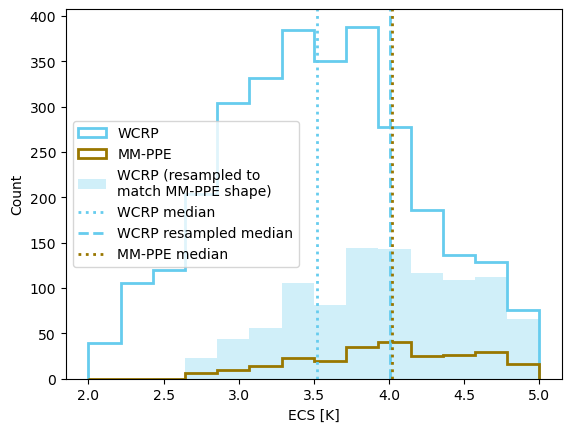

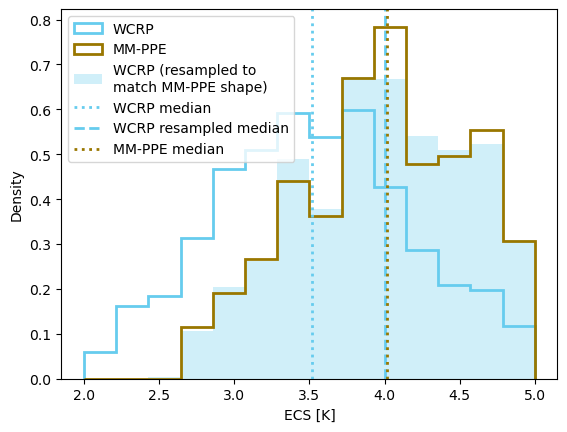

In [9]:
comparison_hist(ds_wcrp["ECS"], ds_mmppe["ECS"], wcrp_ecs_resampled["ECS"], "ECS [K]", bins=np.linspace(2, 5, 15))
comparison_hist(ds_wcrp["ECS"], ds_mmppe["ECS"], wcrp_ecs_resampled["ECS"], "ECS [K]", density=True,  bins=np.linspace(2, 5, 15))


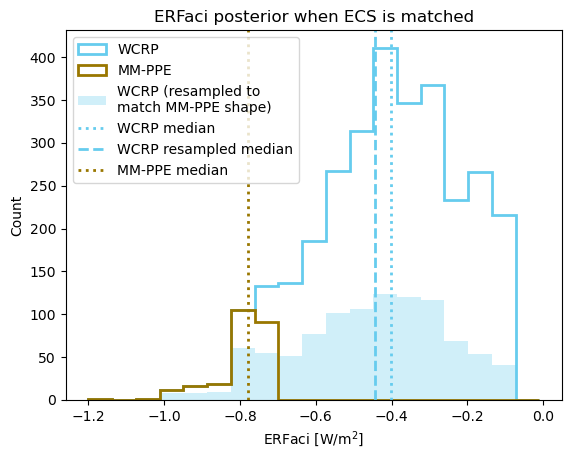

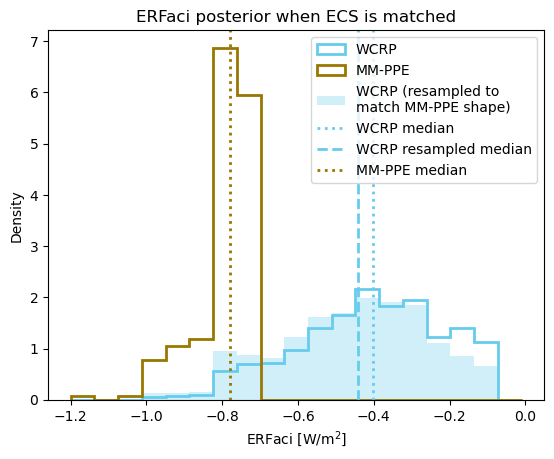

In [10]:
# what does that ERFaci post look like?
comparison_hist(ds_wcrp["ERFaci"], ds_mmppe["ERFaci"], wcrp_ecs_resampled["ERFaci"], "ERFaci [W/m$^2$]", 
                bins=np.linspace(-1.2, -0.01, 20), title="ERFaci posterior when ECS is matched")
comparison_hist(ds_wcrp["ERFaci"], ds_mmppe["ERFaci"], wcrp_ecs_resampled["ERFaci"], "ERFaci [W/m$^2$]", 
                bins=np.linspace(-1.2, -0.01, 20), title="ERFaci posterior when ECS is matched", density=True)


### How does the future temperature projection change?

#### Plots

In [12]:
def compare_future_temps(wcrp, mmppe, wcrp_rs, varmatch, density=True,
                   wcol="#66CCEE", mcol="#997700", bins=10):
    """ Plot quick comparison histogram for 2050-1850 temperature change
    """
    fig, ax = plt.subplots()

    ax.hist(wcrp, histtype="step", label="WCRP", density=density, color=wcol, lw=2, bins=bins)
    
    ax.hist(mmppe, histtype="step", label="MM-PPE", density=density, color=mcol, lw=2, bins=bins)
    
    ax.hist(wcrp_rs, label=f"WCRP (matched {varmatch})", density=density, color=wcol,
            alpha=0.25, bins=bins)
    
    ax.axvline(wcrp.median(), ls=":", color=wcol, lw=2, label="WCRP median")
    ax.axvline(wcrp_rs.median(), ls="--", color=wcol, lw=2, label="WCRP matched median")
    ax.axvline(mmppe.median(), ls=":", color=mcol, lw=2, label="MM-PPE median")
    
    ax.set_xlabel(r"$\Delta\text{GMST}_\text{(2050-1850)}$ [°C]")
    ax.set_ylabel("Density")
    ax.set_title(r"Distribution of Constrained $\Delta\text{GMST}_\text{(2050-1850)}$")

    plt.legend(loc="best")
    plt.show()
    

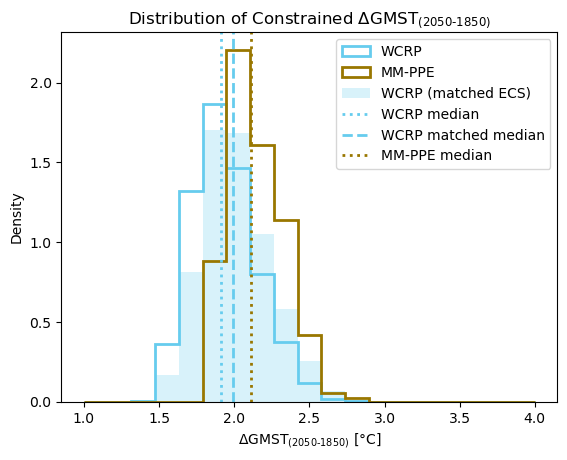

In [13]:
compare_future_temps(ds_wcrp["temp_2050"], ds_mmppe["temp_2050"], wcrp_ecs_resampled["temp_2050"], "ECS", bins=np.linspace(1, 4, 20))


#### Values


In [14]:
# "normal" temperature change - from main text
# (when we allow both ECS and ERFaci to update)
temp_diff = ds_mmppe["temp_2050"].median().values - ds_wcrp["temp_2050"].median().values
print(temp_diff)


0.20276139319823527


In [15]:
# mean instead of median
ds_mmppe["temp_2050"].mean().values - ds_wcrp["temp_2050"].mean().values

0.2053689508189489

In [16]:
# temperature change from updating ERFaci only
# (when we force the posterior ECS distribution to be the same)
temp_diff_erfaci_only = ds_mmppe["temp_2050"].median().values - wcrp_ecs_resampled["temp_2050"].median().values
print(temp_diff_erfaci_only)


0.12220414902781962


In [17]:
# temperature change from updating ECS only
# (when we force the posterior ERFaci distribution to be the same)
temp_diff_ecs_only = ds_mmppe["temp_2050"].median().values - wcrp_erfaci_resampled["temp_2050"].median().values
print(temp_diff_ecs_only)


-0.0006073835054585253


In [18]:
# ~60% of the temperature change comes from updating ERFaci 
temp_diff_erfaci_only / temp_diff * 100.


60.269929645010556

### Clean figures for the SI

##### SSP1-2.6

In [21]:
# temp change - all
print((ds_mmppe["temp_2050"].median() - ds_wcrp["temp_2050"].median()).values)
print(ds_mmppe["temp_2050"].median().values, ds_wcrp["temp_2050"].median().values)


0.20276139319823527
2.113082493777643 1.9103211005794078


In [22]:
# temp change - ERFaci only
print((ds_mmppe["temp_2050"].median() - wcrp_ecs_resampled["temp_2050"].median()).values)
print(ds_mmppe["temp_2050"].median().values, wcrp_ecs_resampled["temp_2050"].median().values)


0.12220414902781962
2.113082493777643 1.9908783447498235


In [23]:
0.12220414902781962/0.20276139319823527 * 100.

60.269929645010556

In [25]:
# with mean vals instead of median
print((ds_mmppe["temp_2050"].mean() - ds_wcrp["temp_2050"].mean()).values)
print(ds_mmppe["temp_2050"].mean().values, ds_wcrp["temp_2050"].mean().values)
print((ds_mmppe["temp_2050"].mean() - wcrp_ecs_resampled["temp_2050"].mean()).values)
print(ds_mmppe["temp_2050"].mean().values, wcrp_ecs_resampled["temp_2050"].mean().values)


0.2053689508189489
2.1406178940292415 1.9352489432102926
0.12646629626087602
2.1406178940292415 2.0141515977683655


In [26]:
0.12646629626087602/0.2053689508189489 * 100.

61.58004691389175

##### SSP2-4.5

In [15]:
# temp change - all
print((ds_mmppe["temp_2050"].median() - ds_wcrp["temp_2050"].median()).values)
print(ds_mmppe["temp_2050"].median().values, ds_wcrp["temp_2050"].median().values)

# temp change - ERFaci only 
print((ds_mmppe["temp_2050"].median() - wcrp_ecs_resampled["temp_2050"].median()).values)
print(ds_mmppe["temp_2050"].median().values, wcrp_ecs_resampled["temp_2050"].median().values)


0.12535048346449162
2.2565036066385415 2.13115312317405
0.03633083098264578
2.2565036066385415 2.2201727756558958


In [16]:
0.03633083098264578/0.12535048346449162*100.


28.983399168888972

In [18]:
# temp change - all
print((ds_mmppe["temp_2050"].mean() - ds_wcrp["temp_2050"].mean()).values)
print(ds_mmppe["temp_2050"].mean().values, ds_wcrp["temp_2050"].mean().values)

# temp change - ERFaci only 
print((ds_mmppe["temp_2050"].mean() - wcrp_ecs_resampled["temp_2050"].mean()).values)
print(ds_mmppe["temp_2050"].mean().values, wcrp_ecs_resampled["temp_2050"].mean().values)


0.1360382774425548
2.2945134241535894 2.1584751467110346
0.05080970177403232
2.2945134241535894 2.243703722379557


In [20]:
0.05080970177403232/0.1360382774425548*100.

37.349562732803534

In [17]:
year_exceed_wcrp = years[np.where(np.median(temp_proj_ts_wcrp, axis=0) > 2)[0][0]]
year_exceed_mmppe = years[np.where(np.median(temp_proj_ts_mmppe, axis=0) > 2)[0][0]]
year_exceed_rs = years[np.where(np.median(temp_proj_rs, axis=0) > 2)[0][0]]

print(year_exceed_wcrp, year_exceed_rs, year_exceed_mmppe)


<xarray.DataArray 'year' ()> Size: 8B
array(2047)
Coordinates:
    year     int64 8B 2047 <xarray.DataArray 'year' ()> Size: 8B
array(2044)
Coordinates:
    year     int64 8B 2044 <xarray.DataArray 'year' ()> Size: 8B
array(2044)
Coordinates:
    year     int64 8B 2044


##### PLots

In [9]:
legsize = 10
labsize = 11
fsize = 13
tsize = 13
wcrp_col = "#66CCEE"
mmppe_col = "#997700"

figsize = (18, 4.5)


In [10]:
# HadCrut obs dataset - relative to 1961-1990
fair_data_path = "/glade/u/home/jnug/work/multi_PPE_data/FaIR_data/"
ds_gmst_s = xr.open_dataset(fair_data_path + "HadCRU_MLE_v1.3_timeseries_monthly_anomalies_summary.nc") #["surface_temperature_anomaly"]

# adjust to 1850 baselines so it's consistent with FaIR
gmst_new_baseline = ds_gmst_s["surface_temperature_anomaly_median"] - ds_gmst_s["surface_temperature_anomaly_median"].sel(time=slice("1850-01-01", "1850-12-31")).mean(dim="time")
gmst_new_baseline = gmst_new_baseline.groupby("time.year").mean()


In [11]:
years = ds_wcrp.year
temp_proj_ts_wcrp = ds_wcrp["temps"]
temp_proj_ts_mmppe = ds_mmppe["temps"]
temp_proj_rs = wcrp_ecs_resampled["temps"]

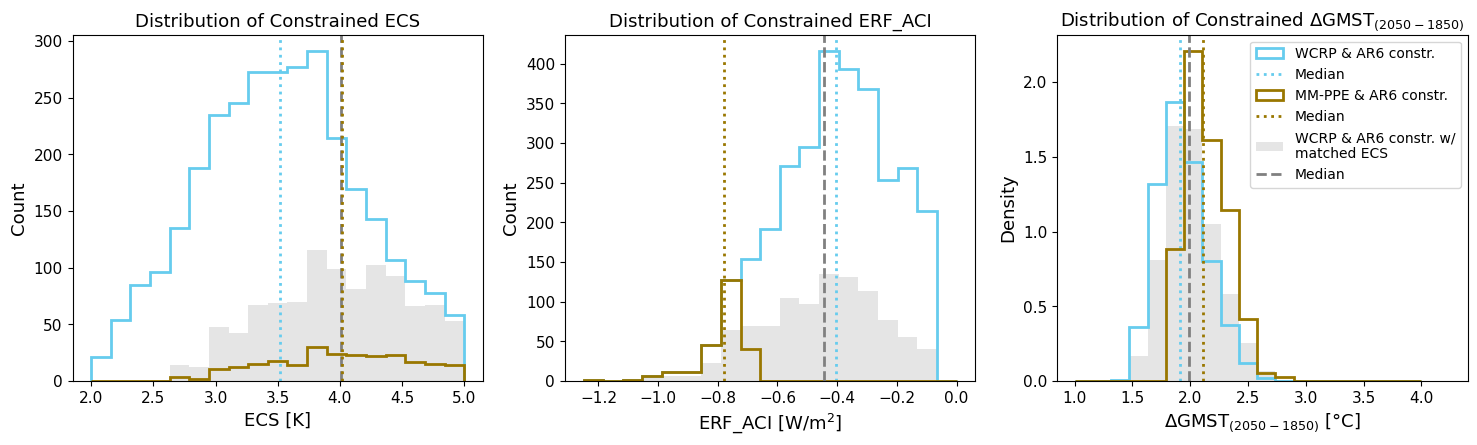

In [146]:
fig, axes = plt.subplots(1, 3, figsize=figsize)

ax_ecs, ax_erfaci, ax_temp = axes
var_list = ["ECS", "ERFaci", "temp_2050"]

for i, var in enumerate(var_list):
    if var == "temp_2050": 
        bins = np.linspace(1, 4, 20)
        dens = True
    elif var == "ECS": 
        bins = np.linspace(2, 5, 20)
        dens = False
    elif var == "ERFaci":
        bins = np.linspace(-1.25, 0, 20)
        dens = False
    
    ax = axes[i]
    ax.hist(ds_wcrp[var], histtype="step", density=dens, bins=bins, label="WCRP & AR6 constr.", linewidth=2, color=wcrp_col)
    ax.axvline(np.median(ds_wcrp[var]), color=wcrp_col, ls=":", lw=2, label="Median")
    
    ax.hist(ds_mmppe[var], histtype="step", density=dens, bins=bins, label="MM-PPE & AR6 constr.", linewidth=2, color=mmppe_col)
    ax.axvline(np.median(ds_mmppe[var]), color=mmppe_col, ls=":", lw=2, label="Median", zorder=99)
    
    ax.hist(wcrp_ecs_resampled[var], density=dens, bins=bins, color="gray", label="WCRP & AR6 constr. w/\nmatched ECS", alpha=0.2)
    ax.axvline(np.median(wcrp_ecs_resampled[var]), color="gray", ls="--", lw=2, label="Median")

    if var == "temp_2050": 
        ax.set_ylabel("Density", fontsize=fsize)
    else:
        ax.set_ylabel("Count", fontsize=fsize)


ax_ecs.set_xlabel("ECS [K]", fontsize=fsize)
ax_ecs.set_title("Distribution of Constrained ECS", fontsize=fsize)

ax_erfaci.set_xlabel("ERF_ACI [W/m$^2$]", fontsize=fsize)
ax_erfaci.set_title("Distribution of Constrained ERF_ACI", fontsize=fsize)

ax_temp.set_xlabel(r"$\Delta$$\mathrm{GMST_{(2050-1850)}}$ [°C]", fontsize=fsize)
ax_temp.set_title(r"Distribution of Constrained $\Delta$$\mathrm{GMST_{(2050-1850)}}$", fontsize=tsize)

ax_temp.set_xlim(right=4.4) # extend slightly for legend visibility

ax_temp.legend(loc="upper right", fontsize=legsize)

for ax in axes:
    ax.tick_params(axis="both", labelsize=labsize)

plt.savefig("./figures/fig_s10_constant_ECS_comp.png", dpi=300, bbox_inches="tight")
plt.show()


In [137]:
year_exceed_wcrp = years[np.where(np.median(temp_proj_ts_wcrp, axis=0) > 2)[0][0]]
year_exceed_mmppe = years[np.where(np.median(temp_proj_ts_mmppe, axis=0) > 2)[0][0]]
year_exceed_rs = years[np.where(np.median(temp_proj_rs, axis=0) > 2)[0][0]]

print(year_exceed_wcrp, year_exceed_rs, year_exceed_mmppe)


<xarray.DataArray 'year' ()> Size: 8B
array(2067)
Coordinates:
    year     int64 8B 2067 <xarray.DataArray 'year' ()> Size: 8B
array(2052)
Coordinates:
    year     int64 8B 2052 <xarray.DataArray 'year' ()> Size: 8B
array(2046)
Coordinates:
    year     int64 8B 2046


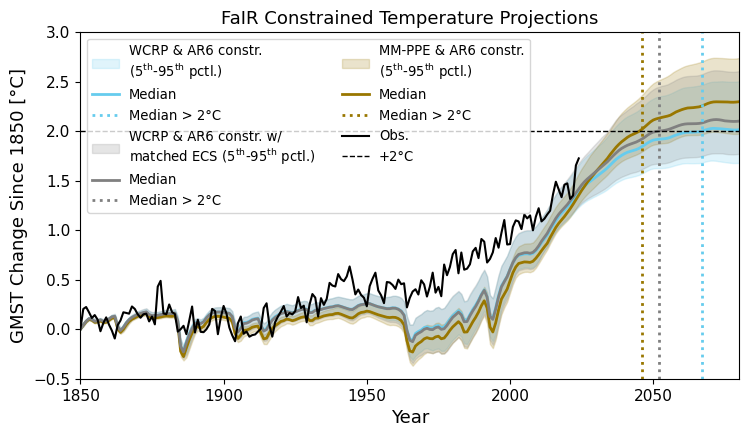

In [145]:
fig, ax_ts = plt.subplots(figsize=(8.5, 4.5))

# shade 5th-95th percentiles & line for median
ax_ts.fill_between(years, np.percentile(temp_proj_ts_wcrp, 5, axis=0), np.percentile(temp_proj_ts_wcrp, 95, axis=0), color=wcrp_col, alpha=0.2,# zorder=0)
                label="WCRP & AR6 constr.\n" + r"(5$^{\mathrm{th}}$-95$^{\mathrm{th}}$ pctl.)", zorder=0) 
ax_ts.fill_between(years, np.percentile(temp_proj_ts_mmppe, 5, axis=0), np.percentile(temp_proj_ts_mmppe, 95, axis=0), color=mmppe_col, alpha=0.2,# zorder=0)
                label="MM-PPE & AR6 constr.\n" + r"(5$^{\mathrm{th}}$-95$^{\mathrm{th}}$ pctl.)", zorder=0)
ax_ts.fill_between(years, np.percentile(temp_proj_rs, 5, axis=0), np.percentile(temp_proj_rs, 95, axis=0), color="gray", alpha=0.2,# zorder=0)
                label="WCRP & AR6 constr. w/\n" + r"matched ECS (5$^{\mathrm{th}}$-95$^{\mathrm{th}}$ pctl.)", zorder=0)


ax_ts.plot(years, np.median(temp_proj_ts_wcrp, axis=0), label="Median",#WCRP and AR6 constraints (median)", 
        linewidth=2, color=wcrp_col)
ax_ts.plot(years, np.median(temp_proj_ts_mmppe, axis=0), label="Median", #MM-PPE and AR6 constraints (median)", 
        linewidth=2, color=mmppe_col)
ax_ts.plot(years, np.median(temp_proj_rs, axis=0), lw=2, label="Median", ls="-", color="gray")

# add obs line
ax_ts.plot(gmst_new_baseline.year, gmst_new_baseline, color="k", label="Obs.")

# axes
ax_ts.set_title("FaIR Constrained Temperature Projections", fontsize=tsize)
ax_ts.set_xlim(1850, 2080)
ax_ts.set_ylabel("GMST Change Since 1850 [°C]", fontsize=fsize)
ax_ts.axhline(2, color="k", ls="--", lw=1, label="+2°C")
ax_ts.axvline(year_exceed_wcrp, color=wcrp_col, ls=":", label="Median > 2°C", lw=2)#WCRP median > 2°C", lw=2)
ax_ts.axvline(year_exceed_mmppe, color=mmppe_col, ls=":", label="Median > 2°C", lw=2)#label="MM-PPE median > 2°C", lw=2)
ax_ts.axvline(year_exceed_rs, color="gray", ls=":", label="Median > 2°C", lw=2)#label="MM-PPE median > 2°C", lw=2)
ax_ts.tick_params(axis="both", labelsize=labsize)
ax_ts.set_xlabel("Year", fontsize=fsize)
ax_ts.set_ylim(-0.5, 3)

# legend
handles, labels = ax_ts.get_legend_handles_labels()
new_order = [0, 3, 8, 2, 5, 10, 1, 4, 9,  6, 7]
new_labels = [labels[x] for x in new_order]
new_handles = [handles[x] for x in new_order]
ax_ts.legend(handles=new_handles, labels=new_labels, fontsize=legsize-0.5, ncol=2)

plt.savefig("./figures/fig_s10_const_ecs_ts.png", dpi=300, bbox_inches="tight")

plt.show()
